# Logistic Regression Model for Predicting March Madness Upsets

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from ISLP import confusion_table
from ISLP.models import summarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import RocCurveDisplay
roc_curve_pred = RocCurveDisplay.from_predictions

In [40]:
# Load the data
data = pd.read_csv('data/matchups_with_differentials.csv')

# Remove missing and infinite values
data = data.replace([np.inf, -np.inf], np.nan).dropna()

X = data[['diff_AdjEM', 'diff_AdjOE', 'diff_AdjDE', 'diff_AdjTempo', 'seed_diff']]
y = data['upset']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                      random_state=314,
                                                      test_size=0.20,
                                                      shuffle=True)

In [41]:
# Model fitting
X_train['intercept'] = np.ones(X_train.shape[0])
X_test['intercept'] = np.ones(X_test.shape[0])

glm = sm.GLM(y_train, X_train, family=sm.families.Binomial())
results = glm.fit()
summarize(results)

,coef,std err,z,P>|z|
diff_AdjEM,-82.5625,186.021,-0.444,0.657
diff_AdjOE,82.4494,186.021,0.443,0.658
diff_AdjDE,-82.4417,186.021,-0.443,0.658
diff_AdjTempo,-0.0059,0.018,-0.323,0.747
seed_diff,0.0373,0.031,1.189,0.235
intercept,-0.3613,0.131,-2.764,0.006


In [43]:
# Predictions
def predict(X, model):
    predictions_df = pd.DataFrame(model.get_prediction(X).predicted,
                                   columns=['y_hat'], index=X.index)
    return predictions_df['y_hat']

probs_train = predict(X_train, results)
probs_test  = predict(X_test, results)

predictions_train = np.array([True]*len(y_train))
predictions_train[probs_train < 0.3] = False

predictions_test = np.array([True]*len(y_test))
predictions_test[probs_test < 0.3] = False

In [70]:
confusion_table(predictions_test, y_test)

TP = ((predictions_test == True)  & (y_test.values == 1)).sum()
TN = ((predictions_test == False) & (y_test.values == 0)).sum()
FP = ((predictions_test == True)  & (y_test.values == 0)).sum()
FN = ((predictions_test == False) & (y_test.values == 1)).sum()

print("=" * 40)
print(f"{'Confusion Matrix':^40}")
print("=" * 40)
print(f"{'':20} {'Predicted No':>8} {'Predicted Yes':>12}")
print(f"{'Actual No':20} {TN:>8} {FP:>12}")
print(f"{'Actual Yes':20} {FN:>8} {TP:>12}")
print("=" * 40)

# Calculate rates
total = TP + TN + FP + FN

fp_rate = FP / (FP + TN)
fn_rate = FN / (FN + TP)
misclass_rate = (FP + FN) / total

print(f"\nFalse Positive Rate:       {FP}/{FP+TN} = {fp_rate:.1%}")
print(f"False Negative Rate:       {FN}/{FN+TP} = {fn_rate:.1%}")
print(f"Total Misclassification:   {FP+FN}/{total} = {misclass_rate:.1%}")

            Confusion Matrix            
                     Predicted No Predicted Yes
Actual No                 112           58
Actual Yes                 35           38

False Positive Rate:       58/170 = 34.1%
False Negative Rate:       35/73 = 47.9%
Total Misclassification:   93/243 = 38.3%


/opt/anaconda3/envs/islp/lib/python3.14/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/opt/anaconda3/envs/islp/lib/python3.14/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


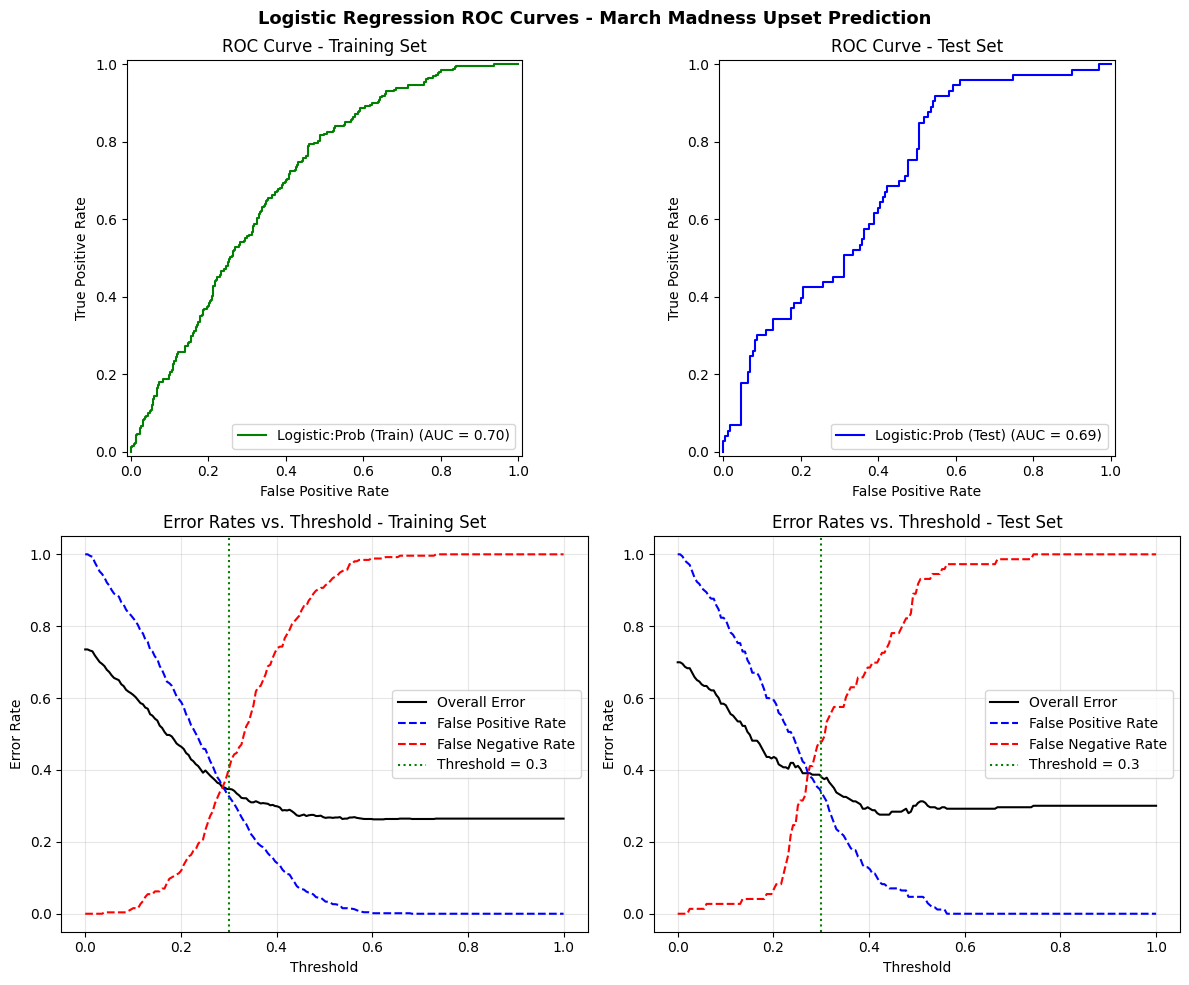

In [66]:
# ROC Curves + Error Rate Plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
ax1, ax2 = axes[0]
ax3, ax4 = axes[1]

# --- Top Row: ROC Curves ---
roc_curve_pred(y_train, probs_train,
               name='Logistic:Prob (Train)',
               color='g', ax=ax1)
ax1.set_title('ROC Curve - Training Set')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')

roc_curve_pred(y_test, probs_test,
               name='Logistic:Prob (Test)',
               color='b', ax=ax2)
ax2.set_title('ROC Curve - Test Set')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')

# --- Bottom Row: Error Rate Plots ---
thresholds = np.linspace(0, 1, 200)

def compute_error_rates(y_true, y_prob, thresholds):
    overall_err, fpr_list, fnr_list = [], [], []
    neg = (y_true == 0).sum()
    pos = (y_true == 1).sum()
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        fp = ((y_pred == 1) & (y_true == 0)).sum()
        fn = ((y_pred == 0) & (y_true == 1)).sum()
        overall_err.append((fp + fn) / len(y_true))
        fpr_list.append(fp / neg if neg > 0 else 0)
        fnr_list.append(fn / pos if pos > 0 else 0)
    return overall_err, fpr_list, fnr_list

# Training error rates
overall_tr, fpr_tr, fnr_tr = compute_error_rates(y_train, probs_train, thresholds)
ax3.plot(thresholds, overall_tr, 'k-',  label='Overall Error')
ax3.plot(thresholds, fpr_tr,    'b--', label='False Positive Rate')
ax3.plot(thresholds, fnr_tr,    'r--', label='False Negative Rate')
ax3.axvline(x=0.3, color='green', linestyle=':', label='Threshold = 0.3')
ax3.set_title('Error Rates vs. Threshold - Training Set')
ax3.set_xlabel('Threshold')
ax3.set_ylabel('Error Rate')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Test error rates
overall_te, fpr_te, fnr_te = compute_error_rates(y_test, probs_test, thresholds)
ax4.plot(thresholds, overall_te, 'k-',  label='Overall Error')
ax4.plot(thresholds, fpr_te,    'b--', label='False Positive Rate')
ax4.plot(thresholds, fnr_te,    'r--', label='False Negative Rate')
ax4.axvline(x=0.3, color='green', linestyle=':', label='Threshold = 0.3')
ax4.set_title('Error Rates vs. Threshold - Test Set')
ax4.set_xlabel('Threshold')
ax4.set_ylabel('Error Rate')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle('Logistic Regression ROC Curves - March Madness Upset Prediction',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Model Confidence Report Function For Indivudual Matchup Cases

In [60]:
def model_confidence_report(fav_name, fav_seed, und_name, und_seed, 
                             year, round_name, prob_value, actual_upset, 
                             threshold=0.3):
    """
    fav_name, und_name: team name strings
    fav_seed, und_seed: seed numbers
    year: int
    round_name: e.g. 'Round of 64'
    prob_value: float, model's predicted upset probability
    actual_upset: bool or int (1 = upset occurred, 0 = no upset)
    threshold: cutoff for predicting upset (default 0.3)
    """
    predicted_upset = prob_value >= threshold
    actual_upset_bool = bool(actual_upset)
    model_correct = predicted_upset == actual_upset_bool

    pred_str = f"UPSET — {und_name} wins" if predicted_upset else f"NO UPSET — {fav_name} wins"
    actual_str = f"UPSET — {und_name} won" if actual_upset_bool else f"No Upset — {fav_name} won"

    print("=" * 50)
    print(f"{'MODEL CONFIDENCE REPORT':^50}")
    print("=" * 50)
    print(f"Matchup:          {fav_name} ({fav_seed}) vs {und_name} ({und_seed})")
    print(f"Year:             {year}, {round_name}")
    print("-" * 50)
    print(f"P(Upset):         {prob_value:.1%}  — {und_name} wins")
    print(f"P(No Upset):      {1-prob_value:.1%}  — {fav_name} wins")
    print("-" * 50)
    print(f"Model Prediction: {pred_str}")
    print(f"Actual Result:    {actual_str}")
    print(f"Model Correct:    {'YES' if model_correct else 'NO'}")
    print("=" * 50)

# UMBC Vs. Virgina 2018, First 1 Vs. 16 seed Upset Ever

In [61]:
# Look up the 2018 Virginia vs UMBC matchup (historic 16 over 1 upset)
matchup_lookup = data[
    (data['Year'] == 2018) &
    (data['fav_name'] == 'Virginia') &
    (data['und_name'] == 'UMBC')
]

print(matchup_lookup[['Year', 'Round', 'fav_name', 'fav_seed', 
                       'und_name', 'und_seed', 'diff_AdjEM', 
                       'diff_AdjOE', 'diff_AdjDE', 'diff_AdjTempo', 
                       'seed_diff', 'upset']].to_string())

      Year        Round  fav_name  fav_seed und_name  und_seed  diff_AdjEM  diff_AdjOE  diff_AdjDE  diff_AdjTempo  seed_diff  upset
1226  2018  Round of 64  Virginia         1     UMBC        16     34.0613      13.139    -20.9217        -8.9945         15      1


In [62]:
# UMBC vs Virginia 2018
prob_value = prob.values[0]
model_confidence_report('Virginia', 1, 'UMBC', 16, 2018, 'Round of 64', 
                         prob_value, actual_upset=1)

             MODEL CONFIDENCE REPORT              
Matchup:          Virginia (1) vs UMBC (16)
Year:             2018, Round of 64
--------------------------------------------------
P(Upset):         2.3%  — UMBC wins
P(No Upset):      97.7%  — Virginia wins
--------------------------------------------------
Model Prediction: NO UPSET — Virginia wins
Actual Result:    UPSET — UMBC won
Model Correct:    NO


# #15 "Dunk City" FGCU Vs. #2 Georgetown in 2013

In [50]:
# Look up the 2013 FGCU vs Georgetown matchup
matchup_lookup = data[
    (data['Year'] == 2013) &
    (data['fav_name'] == 'Georgetown') &
    (data['und_name'] == 'Florida Gulf Coast')
]

print(matchup_lookup[['Year', 'Round', 'fav_name', 'fav_seed', 
                       'und_name', 'und_seed', 'diff_AdjEM', 
                       'diff_AdjOE', 'diff_AdjDE', 'diff_AdjTempo', 
                       'seed_diff', 'upset']].to_string())

     Year        Round    fav_name  fav_seed            und_name  und_seed  diff_AdjEM  diff_AdjOE  diff_AdjDE  diff_AdjTempo  seed_diff  upset
891  2013  Round of 64  Georgetown         2  Florida Gulf Coast        15    18.80947       4.443    -14.3666        -6.7058         13      1


In [63]:
# FGCU vs Georgetown 2013
prob_value = prob.values[0]
model_confidence_report('Georgetown', 2, 'Florida Gulf Coast', 15, 2013, 'Round of 64', 
                         prob_value, actual_upset=1)

             MODEL CONFIDENCE REPORT              
Matchup:          Georgetown (2) vs Florida Gulf Coast (15)
Year:             2013, Round of 64
--------------------------------------------------
P(Upset):         2.3%  — Florida Gulf Coast wins
P(No Upset):      97.7%  — Georgetown wins
--------------------------------------------------
Model Prediction: NO UPSET — Georgetown wins
Actual Result:    UPSET — Florida Gulf Coast won
Model Correct:    NO


# #5 Florida Vs. #4 Illinois in 2000

In [52]:
# Look up the 2000 Illinois vs Florida matchup
matchup_lookup = data[
    (data['Year'] == 2000) &
    (data['fav_name'] == 'Illinois') &
    (data['und_name'] == 'Florida')
]

print(matchup_lookup[['Year', 'Round', 'fav_name', 'fav_seed', 
                       'und_name', 'und_seed', 'diff_AdjEM', 
                       'diff_AdjOE', 'diff_AdjDE', 'diff_AdjTempo', 
                       'seed_diff', 'upset']].to_string())

    Year        Round  fav_name  fav_seed und_name  und_seed  diff_AdjEM  diff_AdjOE  diff_AdjDE  diff_AdjTempo  seed_diff  upset
17  2000  Round of 32  Illinois         4  Florida         5   -2.832989   -9.272882   -6.439893      -1.228646          1      1


In [64]:

# Illinois vs Florida 2000
prob_value = prob.values[0]
model_confidence_report('Illinois', 4, 'Florida', 5, 2000, 'Round of 32', 
                         prob_value, actual_upset=1)

             MODEL CONFIDENCE REPORT              
Matchup:          Illinois (4) vs Florida (5)
Year:             2000, Round of 32
--------------------------------------------------
P(Upset):         2.3%  — Florida wins
P(No Upset):      97.7%  — Illinois wins
--------------------------------------------------
Model Prediction: NO UPSET — Illinois wins
Actual Result:    UPSET — Florida won
Model Correct:    NO


# #4 Syracuse Vs. #5 Kentucky in 2000

In [56]:
# Look up the 2000 Syracuse vs Kentucky matchup
matchup_lookup = data[
    (data['Year'] == 2000) &
    (data['fav_name'] == 'Syracuse') &
    (data['und_name'] == 'Kentucky')
]

print(matchup_lookup[['Year', 'Round', 'fav_name', 'fav_seed', 
                       'und_name', 'und_seed', 'diff_AdjEM', 
                       'diff_AdjOE', 'diff_AdjDE', 'diff_AdjTempo', 
                       'seed_diff', 'upset']].to_string())

   Year        Round  fav_name  fav_seed  und_name  und_seed  diff_AdjEM  diff_AdjOE  diff_AdjDE  diff_AdjTempo  seed_diff  upset
9  2000  Round of 32  Syracuse         4  Kentucky         5   -0.200572    4.531577    4.732149       3.079245          1      0


In [65]:
# Syracuse vs Kentucky 2000
prob_value = prob.values[0]
model_confidence_report('Syracuse', 4, 'Kentucky', 5, 2000, 'Round of 32', 
                         prob_value, actual_upset=0)

             MODEL CONFIDENCE REPORT              
Matchup:          Syracuse (4) vs Kentucky (5)
Year:             2000, Round of 32
--------------------------------------------------
P(Upset):         2.3%  — Kentucky wins
P(No Upset):      97.7%  — Syracuse wins
--------------------------------------------------
Model Prediction: NO UPSET — Syracuse wins
Actual Result:    No Upset — Syracuse won
Model Correct:    YES
